In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Task 01 – Exploratory Data Analysis (EDA)

## Business Problem

A telecom company is losing approximately 26% of its customers every year, resulting in a significant revenue loss. The objective of this analysis is to explore the Telco Customer Churn dataset, identify customer segments that are more likely to churn, and provide business insights through exploratory data analysis.

## Importing Required Libraries

The required Python libraries are imported for data manipulation, numerical computation, and data visualization.

In [7]:
df = pd.read_csv("Telco-Customer-Churn.csv")

## Loading the Dataset

The dataset is loaded into a pandas DataFrame to begin the exploratory data analysis process.

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation

The first five rows provide an overview of the dataset structure and the available customer information.

In [5]:
df.shape

(7043, 21)

### Observation

The shape of the dataset indicates the total number of customer records and available features.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The dataset contains both categorical and numerical features. This summary helps identify data types and any columns that may require preprocessing.

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observation

The statistical summary provides useful information about the distribution of numerical variables such as tenure and monthly charges.

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Observation

The dataset contains customer demographic information, account details, service usage, and the target variable (Churn).

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Observation

Missing values were checked across all columns. Further preprocessing will verify whether any columns contain blank spaces instead of actual null values.

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

Duplicate records were checked to ensure data quality before further analysis.

In [11]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Checking Blank Values in TotalCharges

The `TotalCharges` column was inspected for blank spaces because blank values can prevent the column from being treated as numeric, affecting statistical analysis and visualizations.

In [12]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Observation

Blank spaces in the `TotalCharges` column were replaced with missing values (`NaN`) and the column was converted to a numeric data type. This ensures accurate statistical analysis and visualization.

In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Handling Missing Values

The `TotalCharges` column contained 11 missing values after converting blank spaces to `NaN`. Since these missing records represented a very small portion of the dataset, they were removed using `dropna()`. This approach minimizes the impact on the overall analysis while ensuring data quality.

# Univariate Analysis

Univariate analysis examines one variable at a time to understand its distribution, frequency, and overall characteristics before exploring relationships between multiple variables.

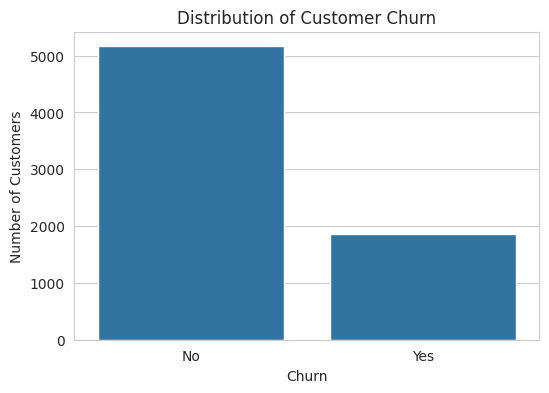

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Churn Distribution

The chart shows the distribution of customers who churned and those who stayed. This provides an initial understanding of the target variable and helps determine whether the dataset is balanced or imbalanced.

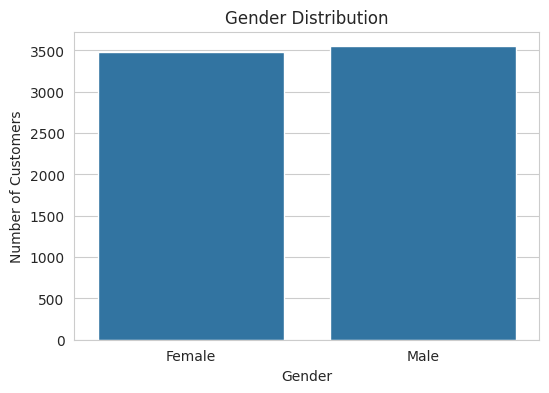

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Gender Distribution

This visualization shows the number of male and female customers in the dataset and helps understand the demographic distribution.

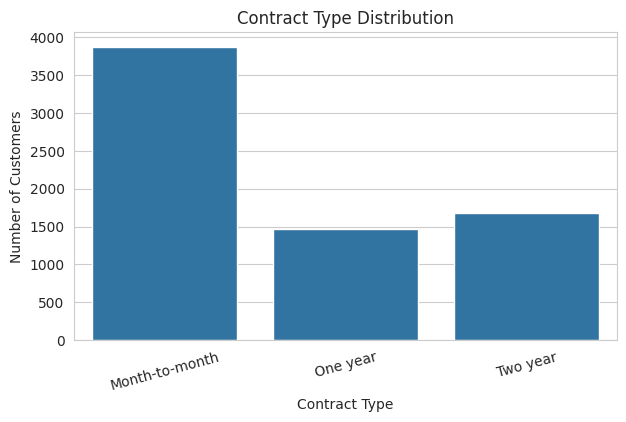

In [20]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Contract Type

The distribution of contract types provides insight into the most common subscription plans among customers.

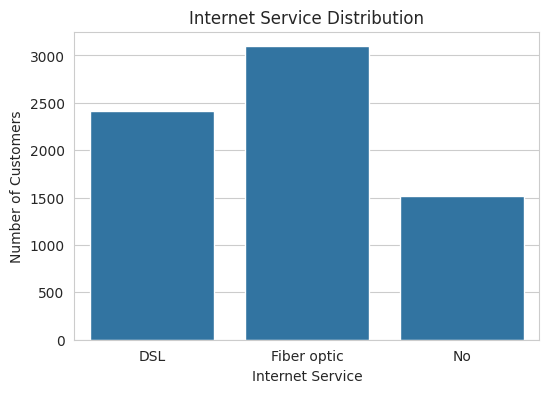

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="InternetService")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

Internet Service

This chart illustrates the distribution of customers across different internet service types.

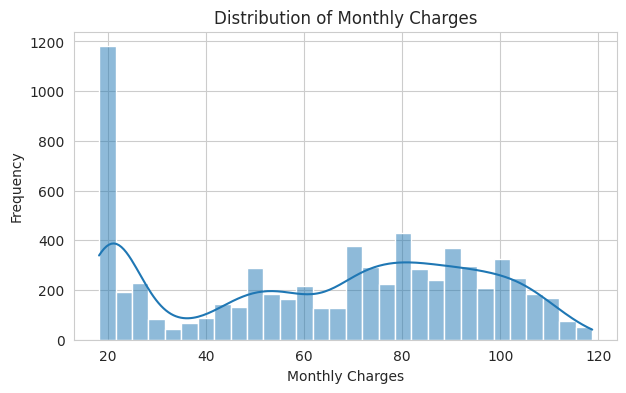

In [22]:
plt.figure(figsize=(7,4))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

### Monhthly Charges

The histogram shows how monthly charges are distributed across customers and helps identify skewness or unusual patterns.

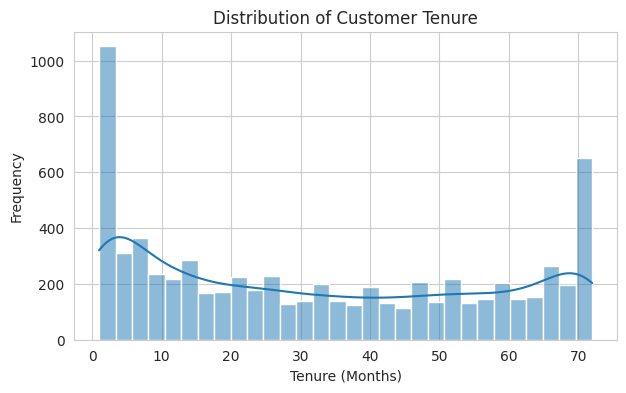

In [23]:
plt.figure(figsize=(7,4))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

### Tenure Distribution

The tenure distribution indicates how long customers have remained with the company and highlights whether most customers are new or long-term subscribers.

# Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this section, different customer attributes are compared with the target variable (Churn) to identify patterns, trends, and factors that may influence customer retention.

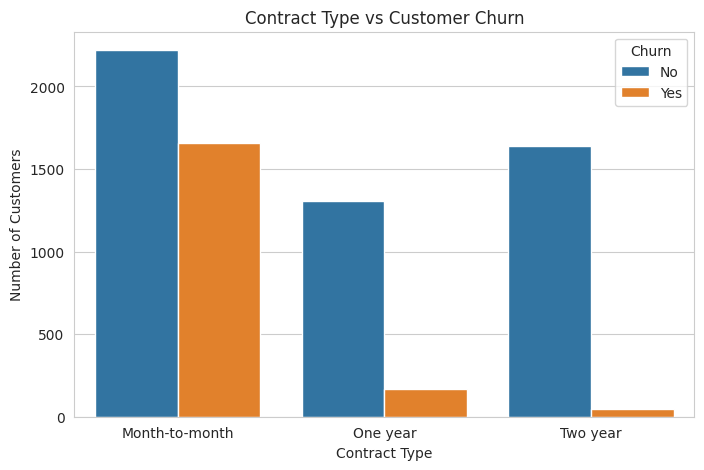

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers with month-to-month contracts appear to have a higher churn rate compared to customers with one-year and two-year contracts. This suggests that long-term contracts may improve customer retention.

Customers with month-to-month contracts have the highest churn compared to customers with one-year and two-year contracts. Customers on longer contracts are more likely to stay with the company, suggesting that long-term contracts improve customer retention.

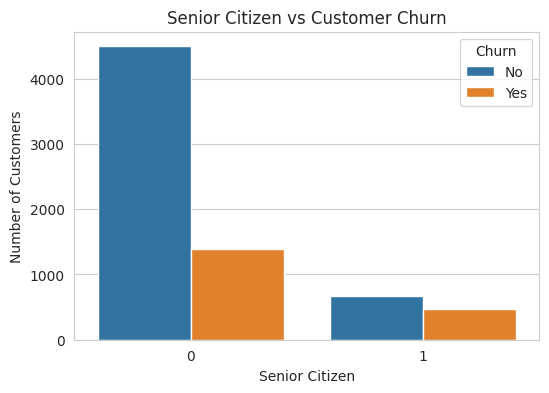

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observation

This visualization compares churn between senior citizens and non-senior customers to identify whether age group influences customer retention.

Most customers are not senior citizens. However, compared to non-senior customers, senior citizens appear to have a relatively higher churn rate. This suggests that senior customers may require additional attention to improve retention.

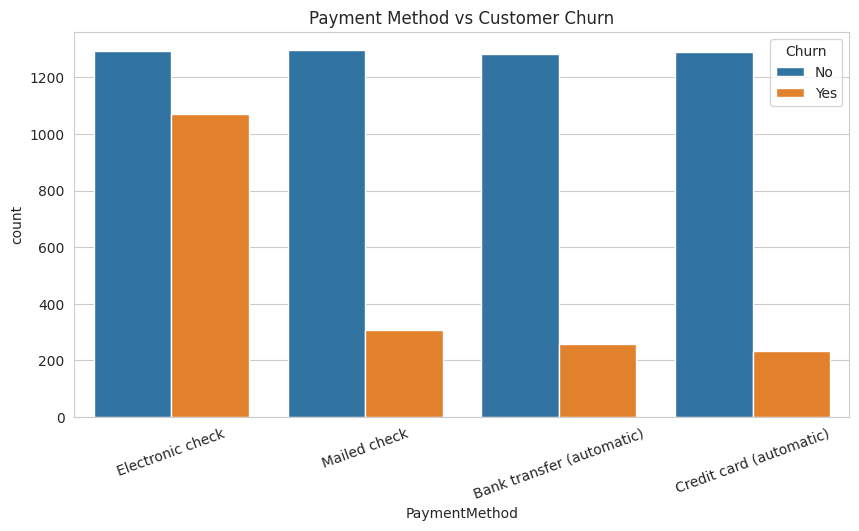

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.xticks(rotation=20)

plt.title("Payment Method vs Customer Churn")

plt.show()

### Observation

This chart shows how customer churn varies across different payment methods.

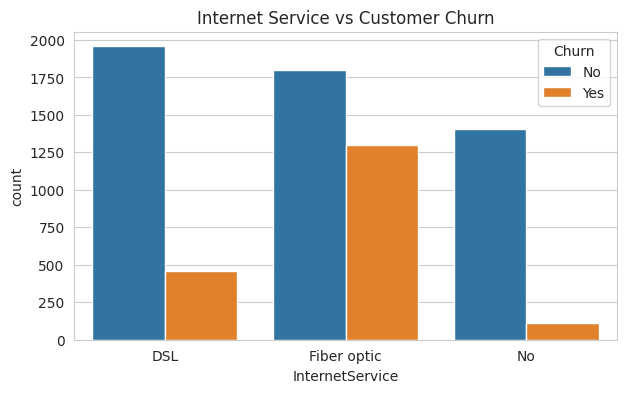

In [27]:
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")

plt.show()

### Observation

The visualization helps determine whether customers using different internet service types experience different churn rates.

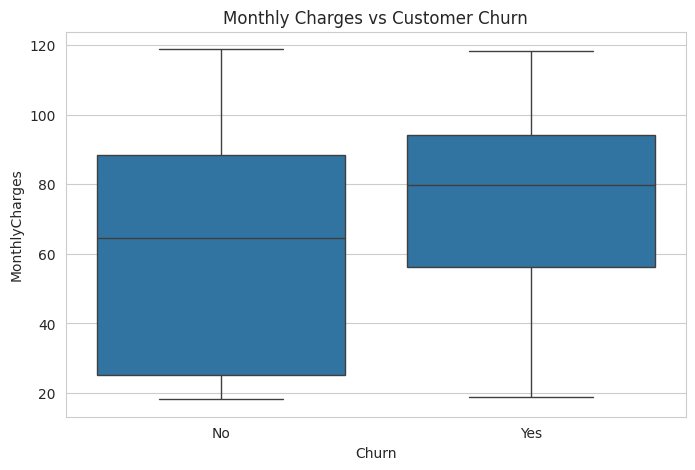

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")

plt.show()

### Observation

The boxplot compares the distribution of monthly charges between customers who churned and those who stayed, helping identify whether higher monthly charges are associated with customer churn.

# Multivariate Analysis

Multivariate analysis examines the relationship among three or more variables simultaneously. This helps identify more complex patterns and interactions that influence customer churn.

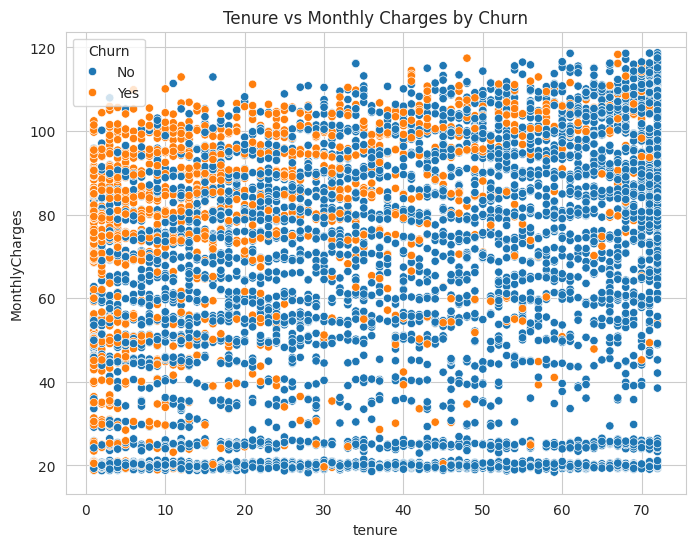

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges by Churn")

plt.show()

### Observation

This scatter plot compares customer tenure and monthly charges while highlighting churn status. It helps identify whether customers with shorter tenure and higher monthly charges are more likely to churn.

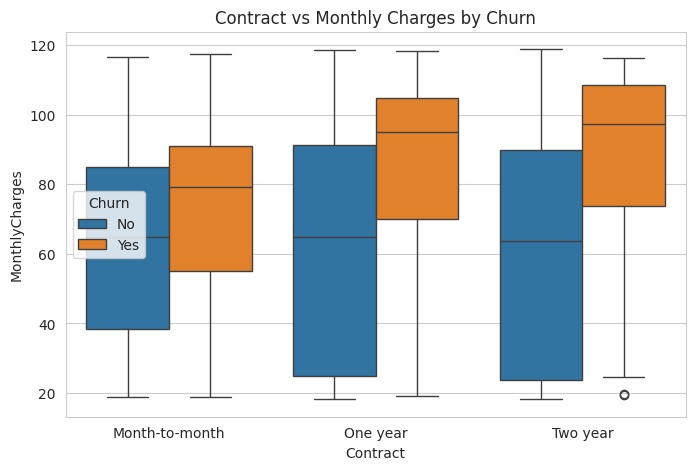

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Contract vs Monthly Charges by Churn")

plt.show()

### Observation

This visualization compares monthly charges across different contract types while distinguishing customers based on churn status.
### Business Insight

The company should review pricing strategies and consider offering discounts or value-added benefits to customers with higher monthly charges, as they may be more likely to leave the service.

# Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. A heatmap is used to visualize these relationships and identify patterns within the dataset.

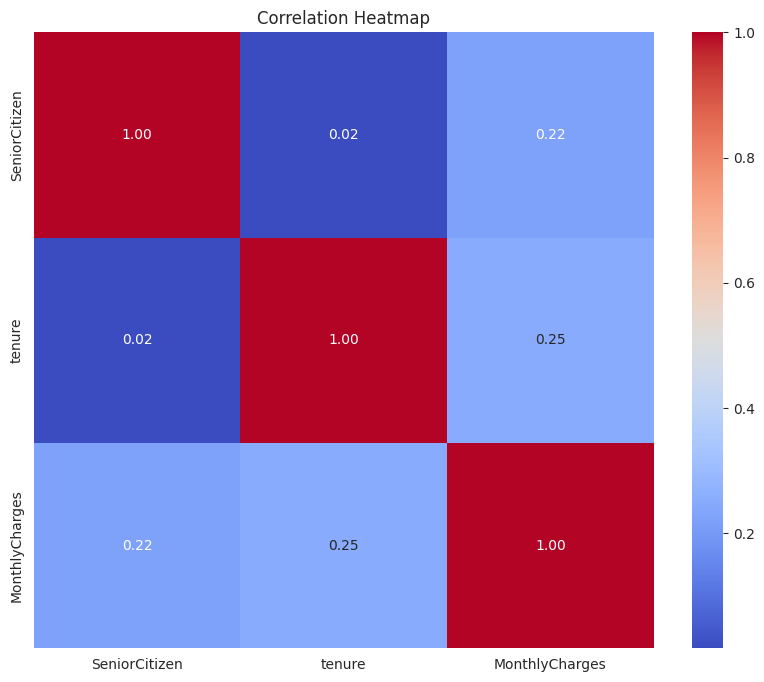

In [9]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the relationships among numerical variables. Variables with values closer to 1 or -1 have stronger positive or negative correlations, while values near 0 indicate weak or no correlation.

# Final Business Insights

- Customers with month-to-month contracts have the highest churn rate.
- Customers with longer contracts are more likely to remain with the company.
- Higher monthly charges appear to be associated with increased customer churn.
- Senior citizens show relatively higher churn compared to non-senior customers.
- The company should focus on retaining month-to-month customers through discounts, loyalty programs, and attractive long-term contract offers.